# 회귀분석
* 지도학습
* 종속변수(target) 변수가 수치형 자료
* 집값, 보험료, 몸무게 과 같이 연속적인 숫자로 이루어진 값을 예측
* 회귀? => 평균으로 돌아간다.

단순 선형 회귀분석 / 다중 선형 회귀분석 
* 단순 선형 회귀분석: 독립변수1, 종속변수1
* 다중 선형 회귀분석: 독립변수n, 종속변수1

1) 단순 회귀 분석: 자동차 배기량과 연비 회귀 분석

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import koreanize_matplotlib

In [4]:
# X는 자동차 배기량, y는 연비
X = np.array([1, 1.4, 1.6, 2, 2.2, 2.4, 3, 3.3, 3.6])
y = np.array([15, 13, 13, 12, 11, 10.5, 10, 9, 8])

# 상수 추가 y절편 추가
X_with_const = sm.add_constant(X)

# 모델 훈련
model = sm.OLS(y, X_with_const).fit()
y_pred = model.predict(X_with_const)

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.967
Model:                            OLS   Adj. R-squared:                  0.962
Method:                 Least Squares   F-statistic:                     203.7
Date:                Wed, 07 May 2025   Prob (F-statistic):           1.97e-06
Time:                        14:12:59   Log-Likelihood:                -3.9965
No. Observations:                   9   AIC:                             11.99
Df Residuals:                       7   BIC:                             12.39
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         16.8291      0.414     40.626      0.0

C:\Users\Admin\miniforge3\envs\fintech\lib\site-packages\scipy\stats\_axis_nan_policy.py:531: UserWarning: kurtosistest only valid for n>=20 ... continuing anyway, n=9
  res = hypotest_fun_out(*samples, **kwds)


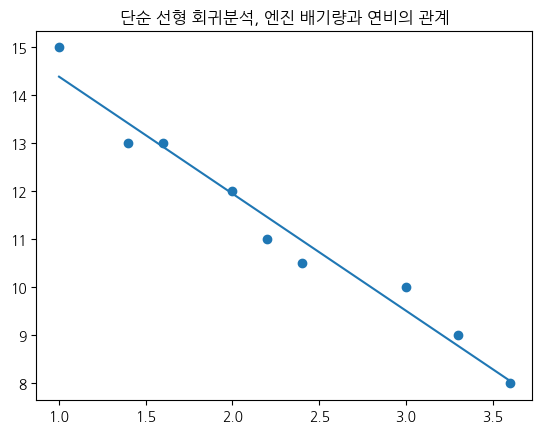

In [6]:
plt.scatter(X,y)
plt.plot(X, y_pred)
plt.title("단순 선형 회귀분석, 엔진 배기량과 연비의 관계")
plt.show()

* R-squared: 0.967로 약 96%를 설명한다.
* p-value: 1.97e-06 로 매우 작다. (0.001 이하, 0.05) 통계적으로 유의미 하다.
* X1의 회귀계수(coefficient-coef)는 -2.4371
* y절편(상수항)은 16.8291
* 따라서 추정되는 회귀식은 y(연비) = -2.4371 * X1 + 16.8291

# 다중 회귀 분석
* 독립변수가 여러 개인 데이터

In [7]:
# 데이터
yard = np.array([31,31,27,39,30,32,28,23,28,35])
area = np.array([58,51,47,35,48,42,43,56,41,41])
park = np.array([1,1,5,5,2,4,5,1,1,3])
dist = np.array([492,426,400,125,443,412,201,362,192,423])
price = np.array([12631,12084,12220,15649,11486,12276,15527,12666,13180,10169])

In [8]:
# 독립변수와 종속 변수 설정
X = pd.DataFrame(dict(yard=yard, area=area, park=park, dist=dist))
y = price

In [9]:
X = sm.add_constant(X)

model = sm.OLS(y, X).fit()
y_pred = model.predict(X)

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.918
Model:                            OLS   Adj. R-squared:                  0.853
Method:                 Least Squares   F-statistic:                     14.07
Date:                Wed, 07 May 2025   Prob (F-statistic):            0.00627
Time:                        14:40:37   Log-Likelihood:                -75.420
No. Observations:                  10   AIC:                             160.8
Df Residuals:                       5   BIC:                             162.4
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       3045.6891   4084.218      0.746      0.4

C:\Users\Admin\miniforge3\envs\fintech\lib\site-packages\scipy\stats\_axis_nan_policy.py:531: UserWarning: kurtosistest only valid for n>=20 ... continuing anyway, n=10
  res = hypotest_fun_out(*samples, **kwds)


1차 분석 결과에서 yard는 p-value가 0.05 보다 컸기 때문에 분석에서 제외

In [ ]:
X2 = pd.DataFrame(dict(area=area, park=park, dist=dist))
X2 = X2

In [ ]:
model2 = sm.OLS(y, X2_const).fit()
print(model2.summary())

In [ ]:
X3_const = X2_const.drop('park', axis=1)

In [ ]:
model3 = sm.OLS(y, X3_const).fit()
print(model3.summary())

# 다중 회귀분석의 회귀식
* y = (92.9476 * area) + (-14.4217 * dist) + 1.351e+04
* 모델의 설명력은 Adj.R-squared를 봐야함 : 0.680
* 모델의 p-value: 0.00766이므로 0.05보다 작음

# 변수 선택
* 전진선택법: 독립변수 0부터 시작해서 변수를 1개씩 추가
* 후진제거법: 모든 독립변수를 다 포함 => 변수를 1개씩 삭제
* 다중선택법: 전진 + 후진
* AIC: 변수를 선택하는 지표

In [10]:
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.linear_model import LinearRegression

In [11]:
# 데이터 생성
yard = np.array([31, 31, 27, 39, 30, 32, 28, 23, 28, 35])
area = np.array([58, 51, 47, 35, 48, 42, 43, 56, 41, 41])
park = np.array([1, 1, 5, 5, 2, 4, 5, 1, 1, 3])
dist = np.array([492, 426, 400, 125, 443, 412, 201, 362, 192, 423])
popul = np.array([4412, 2061, 4407, 1933, 4029, 4180, 3444, 1683, 3020, 4459])
price = np.array([12631, 12084, 12220, 15649, 11486, 12276, 15527, 12666, 13180, 10169])

# 데이터프레임 생성
data = pd.DataFrame({'yard': yard, 'area': area, 'park': park, 'dist': dist, 'popul': popul, 'price': price})

In [13]:
# 독립변수와 종속변수 설정
X = data.drop('price', axis=1)
y = data['price']

In [18]:
# 전진선택법을 사용한 회귀분석
model = LinearRegression()
sfs = SequentialFeatureSelector(model, direction = 'forward')
sfs.fit(X,y)

# 선택된 변수
selected_features = X.columns[sfs.get_support()]
selected_features

Index(['yard', 'park'], dtype='object')

In [21]:
# 최종 선택된 변수로 분석
X_selected = sm.add_constant(data[selected_features])

In [23]:
final_model = sm.OLS(y, X_selected).fit()
print(final_model.summary())

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.194
Model:                            OLS   Adj. R-squared:                 -0.036
Method:                 Least Squares   F-statistic:                    0.8433
Date:                Wed, 07 May 2025   Prob (F-statistic):              0.470
Time:                        15:24:03   Log-Likelihood:                -86.871
No. Observations:                  10   AIC:                             179.7
Df Residuals:                       7   BIC:                             180.6
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        1.22e+04   3990.829      3.056      0.0

C:\Users\Admin\miniforge3\envs\fintech\lib\site-packages\scipy\stats\_axis_nan_policy.py:531: UserWarning: kurtosistest only valid for n>=20 ... continuing anyway, n=10
  res = hypotest_fun_out(*samples, **kwds)
